In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [8]:
repo_folder = Path('../../..')
data_folder  = repo_folder / 'data'/ 'this_project' / '6_transporterKO'
auxotroph_cfus_fn = data_folder / 'E_auxotroph_coculture_CFUs.csv'
cfu_df = pd.read_csv(auxotroph_cfus_fn, index_col=0)

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_83297/2111877142.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_83297/2111877142.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_83297/2111877142.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


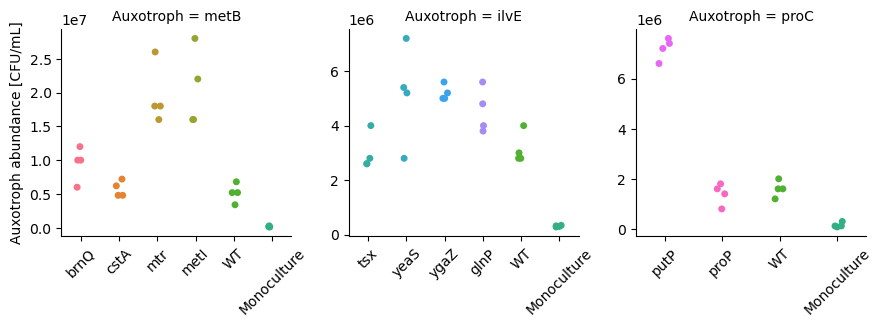

In [10]:
g = sns.catplot(data = cfu_df, x = 'Partner', kind = 'strip', col = 'Auxotroph', y = 'Auxotroph abundance [CFU/mL]',
            hue = 'Partner', col_wrap=3, sharex=False, sharey=False, height = 3)
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('')
# ax.set_ylabel('Auxotroph abundance [CFU/mL]', fontsize = 7)
# plt.tight_layout()

In [59]:
# Filter for Plate 1 (or your plate of interest)
df_plot = cfu_df.loc[cfu_df.Plate == 1]

# Pivot so each partner is a column, indexed by Auxotroph and Well
pivot = df_plot.pivot_table(index=['Partner', 'Well'], columns='Auxotroph', values='Auxotroph abundance [CFU/mL]').reset_index()

# # Compute difference to WT for each partner (excluding WT itself)
# for partner in pivot.columns:
#     if partner != 'WT':
#         pivot[f'diff_{partner}_vs_WT'] = pivot[partner] - pivot['WT']

# # Example: show the differences
# diff_cols = [col for col in pivot.columns if col.startswith('diff_')]
# print(pivot[diff_cols].head())

In [61]:
pivot = pivot.loc[pivot.Partner != 'Monoculture']

In [68]:
diff_data = []
for auxotroph in df_plot['Auxotroph'].unique():
    wt_mean = df_plot.loc[(df_plot.Partner == 'WT')&(df_plot.Auxotroph == auxotroph), 'Auxotroph abundance [CFU/mL]'].mean()
    aux_data = df_plot.loc[df_plot.Auxotroph == auxotroph].copy()
    for i, row in aux_data.iterrows():
        if row['Partner'] in ['WT', 'Monoculture']:
            continue
        diff = row['Auxotroph abundance [CFU/mL]'] - wt_mean
        diff_data.append([row['Partner'], auxotroph, row['Well'], diff])
diff_df = pd.DataFrame(diff_data, columns=['Partner', 'Auxotroph', 'Well', 'Difference_vs_WT'])

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_40720/1010816180.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_40720/1010816180.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_40720/1010816180.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


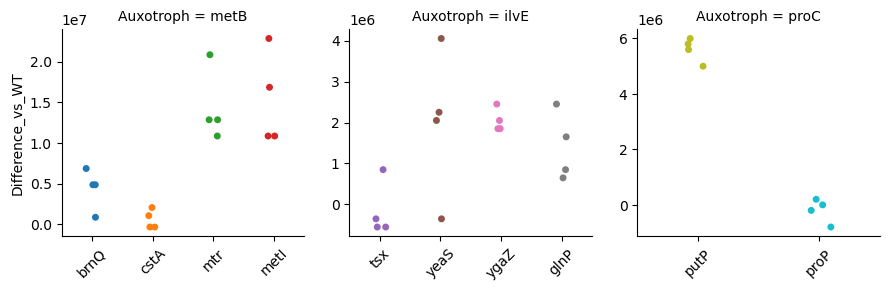

In [70]:
g = sns.catplot(data = diff_df, x = 'Partner', kind = 'strip', col = 'Auxotroph', y = 'Difference_vs_WT',
            hue = 'Partner', col_wrap=3, sharex=False, sharey=False, height = 3)
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('')
# ax.set_ylabel('Auxotroph abundance [CFU/mL]', fontsize = 7)
# plt.tight_layout()